In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from rich import print
import numpy as np

from pymcsimmod.parser import ModelParser

from pymcsimmod import JaxModel, ScipyModel, JaxModelEqx

In [2]:
filename = Path("../../tests/data/pk1_dosing.model")
assert filename.exists()
print(filename.absolute().resolve())

/data/tzurlind/Desktop/PKWG/PyMCSimMod/tests/data/pk1_dosing.model

In [3]:
parser = ModelParser()
parsed_model = parser.parse(filename.read_text())

# Scipy model

<Axes: xlabel='Time', ylabel='Value'>

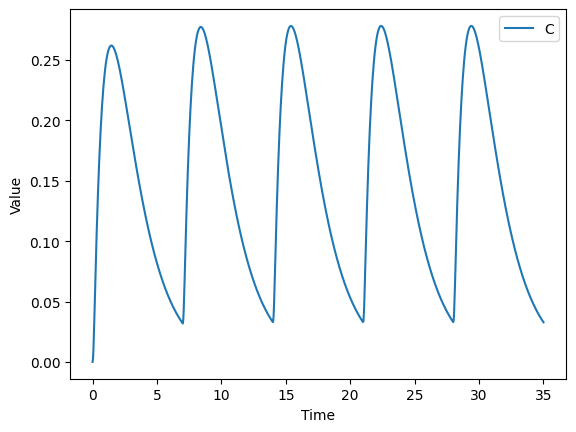

In [4]:
scipy_model = ScipyModel(model=filename)
scipy_model.update_constants(OralDose=50)
scipy_model.assign_forcing_function('OralExp', 'PerDose', t0=0, duration=scipy_model.parameters['OralDur'], period=7)
times = np.linspace(0, 35, 1000)
solution = scipy_model.run_model(times)
solution.plot_results(variables='C')

# Jax

CPU times: user 1.29 s, sys: 254 ms, total: 1.54 s
Wall time: 1.16 s


<Axes: xlabel='Time', ylabel='Value'>

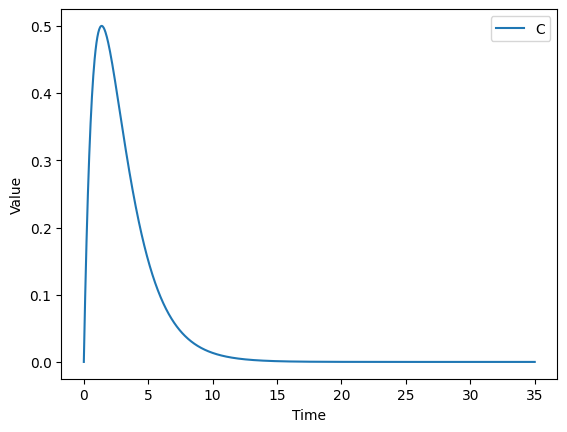

In [ ]:
%%time

jax_model = JaxModel(model=filename)
jax_model.update_Y0(A0=50.)
#jax_model.update_constants(OralDose=100)
#jax_model.assign_forcing_function('OralExp', 'PerDose', t0=0, duration=jax_model.parameters['OralDur'], period=7)
times = np.linspace(0, 35, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')

{'OralExp': <function JaxModelEqx.PerDose.<locals>.func at 0x7f05cc1125c0>}
CPU times: user 1.09 s, sys: 105 ms, total: 1.2 s
Wall time: 900 ms


<Axes: xlabel='Time', ylabel='Value'>

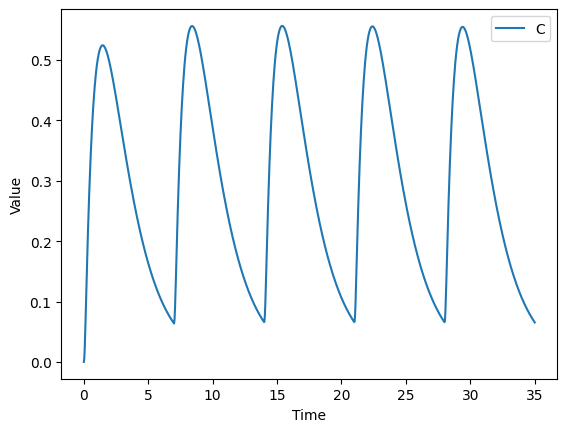

In [4]:
%%time

jax_model = JaxModelEqx.from_model(model=filename)
#jax_model = jax_model.update_Y0(A0=50.)
jax_model = jax_model.update_constants(OralDose=100)
jax_model = jax_model.assign_forcing_function('OralExp', 'PerDose', t0=0, duration=jax_model.parameters['OralDur'], period=7)
times = np.linspace(0, 35, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')